Imports

In [7]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
import shap

Load Data

In [8]:
train_df = pd.read_csv("data/UNSW_NB15_training-set.csv")
test_df = pd.read_csv("data/UNSW_NB15_testing-set.csv")

print(train_df.shape, test_df.shape)
train_df.head()

(82332, 45) (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


Inspect Columns

In [9]:
train_df.columns.tolist()

['id',
 'dur',
 'proto',
 'service',
 'state',
 'spkts',
 'dpkts',
 'sbytes',
 'dbytes',
 'rate',
 'sttl',
 'dttl',
 'sload',
 'dload',
 'sloss',
 'dloss',
 'sinpkt',
 'dinpkt',
 'sjit',
 'djit',
 'swin',
 'stcpb',
 'dtcpb',
 'dwin',
 'tcprtt',
 'synack',
 'ackdat',
 'smean',
 'dmean',
 'trans_depth',
 'response_body_len',
 'ct_srv_src',
 'ct_state_ttl',
 'ct_dst_ltm',
 'ct_src_dport_ltm',
 'ct_dst_sport_ltm',
 'ct_dst_src_ltm',
 'is_ftp_login',
 'ct_ftp_cmd',
 'ct_flw_http_mthd',
 'ct_src_ltm',
 'ct_srv_dst',
 'is_sm_ips_ports',
 'attack_cat',
 'label']

Prepare Binary Task

In [10]:
target = "label"
drop_cols = [c for c in ["id", "attack_cat", target] if c in train_df.columns]

X_train = train_df.drop(columns=drop_cols).copy()
y_train = train_df[target].copy()

X_test = test_df.drop(columns=drop_cols).copy()
y_test = test_df[target].copy()

X_train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports
0,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,...,1,1,1,2,0,0,0,1,2,0
1,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,...,1,1,1,2,0,0,0,1,2,0
2,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,...,1,1,1,3,0,0,0,1,3,0
3,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,...,2,2,1,3,0,0,0,2,3,0
4,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,...,2,2,1,3,0,0,0,2,3,0


Encode Categoricals

In [11]:
categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
categorical_cols

['proto', 'service', 'state']

In [12]:
X_train = pd.get_dummies(X_train, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(X_train.shape, X_test.shape)

(82332, 187) (175341, 187)


# Decision Tree Lab

In [13]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=100,
    random_state=42
)
dt_model.fit(X_train, y_train)

dt_preds = dt_model.predict(X_test)

print("Decision Tree")
print("Accuracy:", accuracy_score(y_test, dt_preds))
print("Precision:", precision_score(y_test, dt_preds))
print("Recall:", recall_score(y_test, dt_preds))
print("F1:", f1_score(y_test, dt_preds))

Decision Tree
Accuracy: 0.8988029040555261
Precision: 0.962052373545811
Recall: 0.8862754627495999
F1: 0.9226105843459146


Plot the Tree

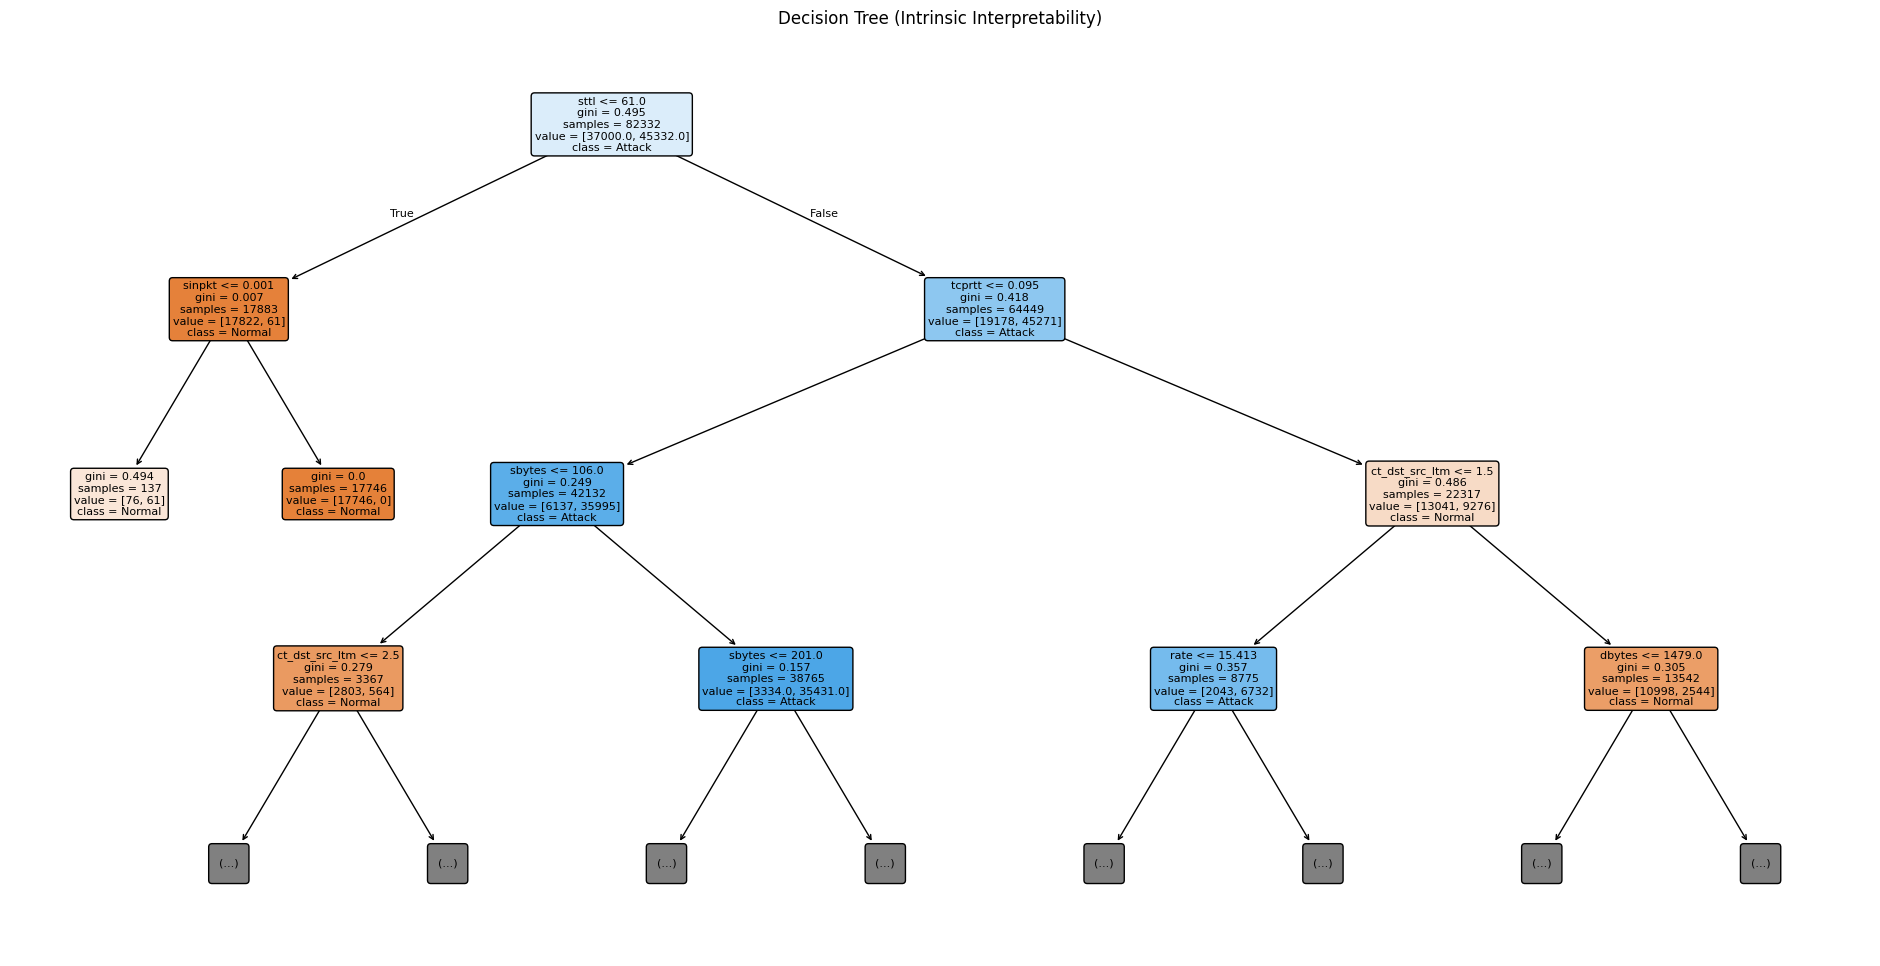

In [14]:
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=["Normal", "Attack"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3
)
plt.title("Decision Tree (Intrinsic Interpretability)")
plt.show()

Show Top Tree Importances

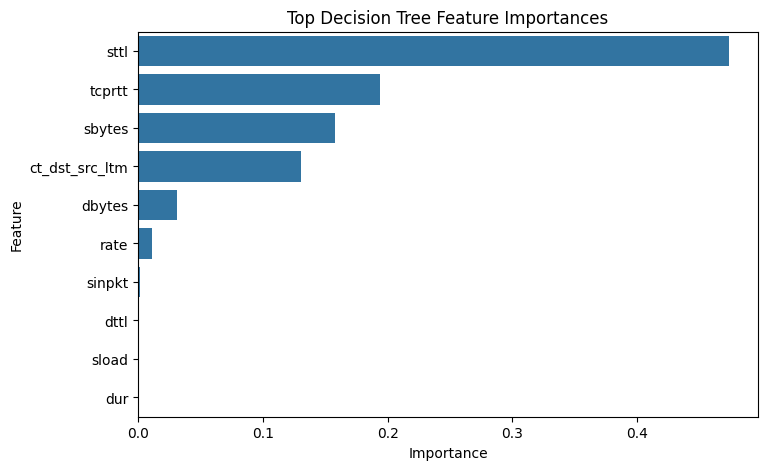

In [15]:
dt_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
dt_top = dt_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=dt_top.values, y=dt_top.index)
plt.title("Top Decision Tree Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# XGBoost Lab

In [16]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds))
print("Recall:", recall_score(y_test, xgb_preds))
print("F1:", f1_score(y_test, xgb_preds))

XGBoost
Accuracy: 0.8996070514026954
Precision: 0.9883267735432466
Recall: 0.8626875926965586
F1: 0.9212432497729418


# SHAP Lab

Global Explanation

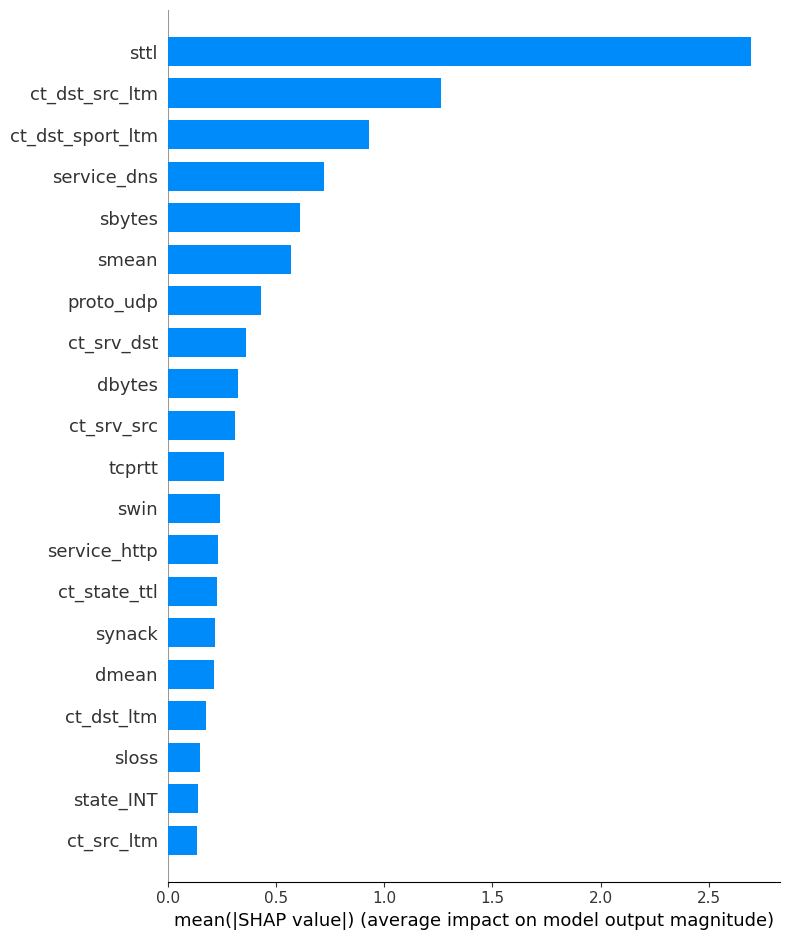

In [17]:
explainer = shap.TreeExplainer(xgb_model)
sample_X = X_test.sample(min(1000, len(X_test)), random_state=42)
shap_values = explainer.shap_values(sample_X)

shap.summary_plot(shap_values, sample_X, plot_type="bar")

Local Explanation

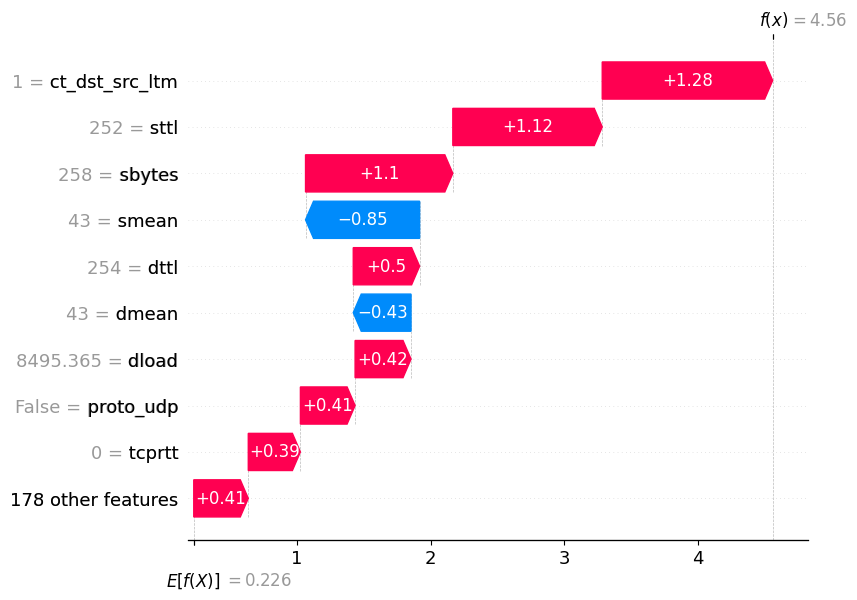

In [18]:
sample_idx = np.where(xgb_preds == 1)[0][0]
one_x = X_test.iloc[[sample_idx]]

one_shap = explainer.shap_values(one_x)
shap.plots.waterfall(
    shap.Explanation(
        values=one_shap[0],
        base_values=explainer.expected_value,
        data=one_x.iloc[0].values,
        feature_names=one_x.columns
    )
)

# Explanation Quality Analysis

In this section, we test:
1. Fidelity via feature masking:
    - If we mask the top-important features, does the model prediction change a lot?
    - If we mask low-importance features, does the prediction stay more stable?

 2. Stability via perturbation:
    - If we slightly perturb low-importance numeric features, do SHAP explanations
      remain similar or do they change drastically?

Helper Functions

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

In [20]:
def get_positive_class_score(model, X):
    """
    Returns the positive-class score for each row.
    Works for sklearn trees and XGBoost classifiers with predict_proba.
    """
    proba = model.predict_proba(X)
    return proba[:, 1]


def mask_features_with_reference(X, feature_names, reference_row):
    """
    Replace selected features in X with reference values (e.g., training-set medians/modes).
    """
    X_masked = X.copy()
    for f in feature_names:
        X_masked[f] = reference_row[f]
    return X_masked


def top_k_features_from_importance(importances, k=3):
    """
    importances can be a pandas Series indexed by feature name.
    """
    return importances.sort_values(ascending=False).head(k).index.tolist()


def bottom_k_features_from_importance(importances, k=3):
    return importances.sort_values(ascending=True).head(k).index.tolist()

Build reference values for masking

In [21]:
reference_values = X_train.median(numeric_only=True)

# In case any non-numeric columns somehow remain, fill them with mode
for col in X_train.columns:
    if col not in reference_values.index:
        reference_values[col] = X_train[col].mode().iloc[0]

reference_values = reference_values[X_train.columns]
reference_values.head()

dur         0.014138
spkts       6.000000
dpkts       2.000000
sbytes    534.000000
dbytes    178.000000
dtype: float64

Feature importance sources for each model

Decision Tree:

In [22]:
dt_importances = pd.Series(dt_model.feature_importances_, index=X_train.columns)
dt_importances = dt_importances.sort_values(ascending=False)
dt_importances.head(10)

sttl              0.473163
tcprtt            0.194220
sbytes            0.157535
ct_dst_src_ltm    0.130703
dbytes            0.031187
rate              0.011328
sinpkt            0.001864
dttl              0.000000
sload             0.000000
dur               0.000000
dtype: float64

Global SHAP importance

In [23]:
sample_X = X_test.sample(min(1000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values_sample = explainer.shap_values(sample_X)

xgb_shap_global = pd.Series(
    np.abs(shap_values_sample).mean(axis=0),
    index=sample_X.columns
).sort_values(ascending=False)

xgb_shap_global.head(10)

sttl                2.694175
ct_dst_src_ltm      1.261288
ct_dst_sport_ltm    0.931601
service_dns         0.721280
sbytes              0.609457
smean               0.570368
proto_udp           0.429408
ct_srv_dst          0.360519
dbytes              0.326516
ct_srv_src          0.309156
dtype: float32

Feature masking test: Decision Tree

This checks whether masking the tree’s top features hurts predictions more than masking low-importance features.

In [24]:
dt_top3 = top_k_features_from_importance(dt_importances, k=3)
dt_bottom3 = bottom_k_features_from_importance(dt_importances, k=3)

print("Decision Tree top 3 important features:", dt_top3)
print("Decision Tree bottom 3 important features:", dt_bottom3)

Decision Tree top 3 important features: ['sttl', 'tcprtt', 'sbytes']
Decision Tree bottom 3 important features: ['dttl', 'dloss', 'dinpkt']


In [25]:
# Use a manageable subset for speed and clarity
mask_test_X = X_test.sample(min(2000, len(X_test)), random_state=42)
mask_test_y = y_test.loc[mask_test_X.index]

dt_base_scores = get_positive_class_score(dt_model, mask_test_X)
dt_base_preds = (dt_base_scores >= 0.5).astype(int)

dt_top_masked_X = mask_features_with_reference(mask_test_X, dt_top3, reference_values)
dt_bottom_masked_X = mask_features_with_reference(mask_test_X, dt_bottom3, reference_values)

dt_top_scores = get_positive_class_score(dt_model, dt_top_masked_X)
dt_bottom_scores = get_positive_class_score(dt_model, dt_bottom_masked_X)

dt_top_preds = (dt_top_scores >= 0.5).astype(int)
dt_bottom_preds = (dt_bottom_scores >= 0.5).astype(int)

dt_results = pd.DataFrame({
    "Condition": ["Original", "Mask Top-3", "Mask Bottom-3"],
    "Accuracy": [
        accuracy_score(mask_test_y, dt_base_preds),
        accuracy_score(mask_test_y, dt_top_preds),
        accuracy_score(mask_test_y, dt_bottom_preds),
    ],
    "Mean Attack Score": [
        dt_base_scores.mean(),
        dt_top_scores.mean(),
        dt_bottom_scores.mean(),
    ],
    "Mean |Score Change|": [
        0.0,
        np.mean(np.abs(dt_top_scores - dt_base_scores)),
        np.mean(np.abs(dt_bottom_scores - dt_base_scores)),
    ],
    "Prediction Flip Rate": [
        0.0,
        np.mean(dt_top_preds != dt_base_preds),
        np.mean(dt_bottom_preds != dt_base_preds),
    ]
})

dt_results

,Condition,Accuracy,Mean Attack Score,Mean |Score Change|,Prediction Flip Rate
0,Original,0.8905,0.587571,0.000000,0.0000
1,Mask Top-3,0.6860,0.726096,0.367932,0.3735
2,Mask Bottom-3,0.8905,0.587571,0.000000,0.0000


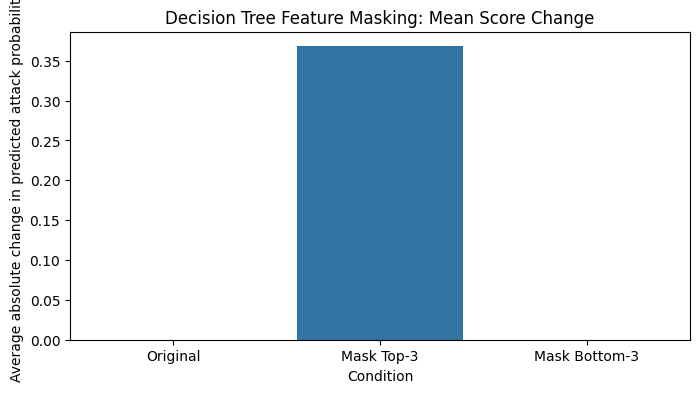

In [26]:
plt.figure(figsize=(8, 4))
sns.barplot(data=dt_results, x="Condition", y="Mean |Score Change|")
plt.title("Decision Tree Feature Masking: Mean Score Change")
plt.ylabel("Average absolute change in predicted attack probability")
plt.show()

Feature masking test: XGBoost using SHAP global importance

In [27]:
xgb_top3 = top_k_features_from_importance(xgb_shap_global, k=3)
xgb_bottom3 = bottom_k_features_from_importance(xgb_shap_global, k=3)

print("XGBoost SHAP top 3 important features:", xgb_top3)
print("XGBoost SHAP bottom 3 important features:", xgb_bottom3)

XGBoost SHAP top 3 important features: ['sttl', 'ct_dst_src_ltm', 'ct_dst_sport_ltm']
XGBoost SHAP bottom 3 important features: ['dwin', 'proto_dcn', 'proto_crudp']


In [28]:
xgb_base_scores = get_positive_class_score(xgb_model, mask_test_X)
xgb_base_preds = (xgb_base_scores >= 0.5).astype(int)

xgb_top_masked_X = mask_features_with_reference(mask_test_X, xgb_top3, reference_values)
xgb_bottom_masked_X = mask_features_with_reference(mask_test_X, xgb_bottom3, reference_values)

xgb_top_scores = get_positive_class_score(xgb_model, xgb_top_masked_X)
xgb_bottom_scores = get_positive_class_score(xgb_model, xgb_bottom_masked_X)

xgb_top_preds = (xgb_top_scores >= 0.5).astype(int)
xgb_bottom_preds = (xgb_bottom_scores >= 0.5).astype(int)

xgb_results = pd.DataFrame({
    "Condition": ["Original", "Mask Top-3", "Mask Bottom-3"],
    "Accuracy": [
        accuracy_score(mask_test_y, xgb_base_preds),
        accuracy_score(mask_test_y, xgb_top_preds),
        accuracy_score(mask_test_y, xgb_bottom_preds),
    ],
    "Mean Attack Score": [
        xgb_base_scores.mean(),
        xgb_top_scores.mean(),
        xgb_bottom_scores.mean(),
    ],
    "Mean |Score Change|": [
        0.0,
        np.mean(np.abs(xgb_top_scores - xgb_base_scores)),
        np.mean(np.abs(xgb_bottom_scores - xgb_base_scores)),
    ],
    "Prediction Flip Rate": [
        0.0,
        np.mean(xgb_top_preds != xgb_base_preds),
        np.mean(xgb_bottom_preds != xgb_base_preds),
    ]
})

xgb_results

,Condition,Accuracy,Mean Attack Score,Mean |Score Change|,Prediction Flip Rate
0,Original,0.889,0.600907,0.000000,0.000
1,Mask Top-3,0.652,0.814994,0.248369,0.281
2,Mask Bottom-3,0.889,0.600907,0.000000,0.000


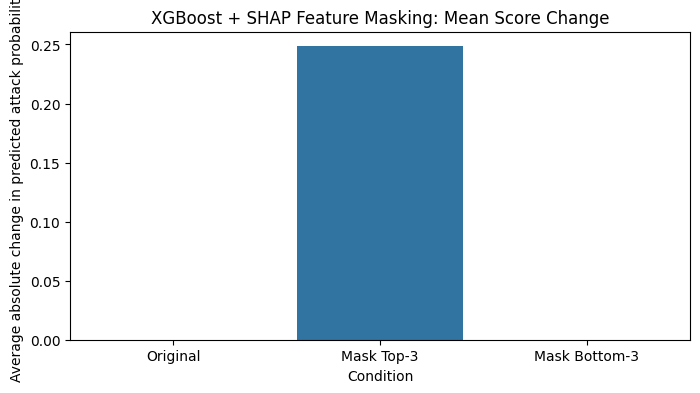

In [29]:
plt.figure(figsize=(8, 4))
sns.barplot(data=xgb_results, x="Condition", y="Mean |Score Change|")
plt.title("XGBoost + SHAP Feature Masking: Mean Score Change")
plt.ylabel("Average absolute change in predicted attack probability")
plt.show()

# SHAP perturbation stability test

Now test whether SHAP explanations for one instance stay similar when you make tiny changes to low-importance numeric features.

Choose which low importance features to perturb.

In [30]:
numeric_cols = X_test.select_dtypes(include=[np.number]).columns.tolist()

# Restrict to numeric features that are also relatively low importance globally
candidate_low_importance = [
    f for f in xgb_shap_global.sort_values(ascending=True).index.tolist()
    if f in numeric_cols
]

perturb_features = candidate_low_importance[:5]
print("Perturbation features:", perturb_features)

Perturbation features: ['dwin', 'state_CLO', 'state_CON', 'is_sm_ips_ports', 'is_ftp_login']


Choose a confidently predicted sample

In [31]:
xgb_test_scores = get_positive_class_score(xgb_model, X_test)
attack_candidates = X_test.index[xgb_test_scores >= 0.9]

sample_idx = attack_candidates[0] if len(attack_candidates) > 0 else X_test.index[0]
x_original = X_test.loc[[sample_idx]].copy()

print("Chosen sample index:", sample_idx)
print("Original predicted attack probability:", get_positive_class_score(xgb_model, x_original)[0])

Chosen sample index: 0
Original predicted attack probability: 0.9896511


Get original SHAP explanation

In [32]:
orig_shap = explainer.shap_values(x_original)[0]
orig_shap_series = pd.Series(orig_shap, index=X_test.columns)
orig_top10 = orig_shap_series.abs().sort_values(ascending=False).head(10)
orig_top10

ct_dst_src_ltm    1.275954
sttl              1.118644
sbytes            1.102697
smean             0.854054
dttl              0.496775
dmean             0.432485
dload             0.418732
proto_udp         0.409493
tcprtt            0.390178
synack            0.266193
dtype: float32

Now slightly perturb the low importance values

In [39]:
rng = np.random.default_rng(42)

feature_stds = X_train[perturb_features].std()

n_perturbations = 20

x_original = X_test.loc[[sample_idx]].copy()
x_original[perturb_features] = x_original[perturb_features].astype(float)

perturbed_rows = []
for i in range(n_perturbations):
    x_pert = x_original.copy()
    for f in perturb_features:
        noise = rng.normal(0, 0.05 * feature_stds[f])
        x_pert.loc[x_pert.index[0], f] = x_pert.loc[x_pert.index[0], f] + noise
    perturbed_rows.append(x_pert)

perturbed_df = pd.concat(perturbed_rows, axis=0)

Compare the prediction and SHAP explanation

In [42]:
orig_score = get_positive_class_score(xgb_model, x_original)[0]
pert_scores = get_positive_class_score(xgb_model, perturbed_df)

pert_shap = explainer.shap_values(perturbed_df)

# Compare each perturbed SHAP vector to the original
cos_sims = []
top10_overlap = []

orig_top10_features = set(orig_shap_series.abs().sort_values(ascending=False).head(10).index)

for i in range(len(perturbed_df)):
    cur_shap = pert_shap[i]
    sim = cosine_similarity([orig_shap], [cur_shap])[0, 0]
    cos_sims.append(sim)

    cur_top10_features = set(
        pd.Series(cur_shap, index=X_test.columns).abs().sort_values(ascending=False).head(10).index
    )
    overlap = len(orig_top10_features.intersection(cur_top10_features)) / 10.0
    top10_overlap.append(overlap)

stability_results = pd.DataFrame({
    "Perturbed Prediction": pert_scores,
    "Prediction Change": np.abs(pert_scores - orig_score),
    "SHAP Cosine Similarity": cos_sims,
    "Top-10 Feature Overlap": top10_overlap
})

stability_results[[
    "Prediction Change",
    "SHAP Cosine Similarity",
    "Top-10 Feature Overlap"
]].describe()

,Prediction Change,SHAP Cosine Similarity,Top-10 Feature Overlap
count,20.0,20.0,20.0
mean,0.0,1.0,1.0
std,0.0,0.0,0.0
min,0.0,1.0,1.0
25%,0.0,1.0,1.0
50%,0.0,1.0,1.0
75%,0.0,1.0,1.0
max,0.0,1.0,1.0


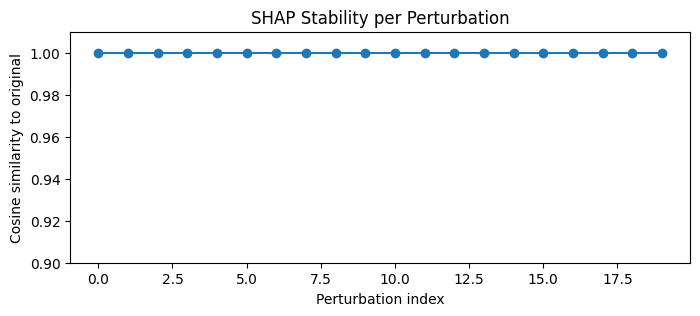

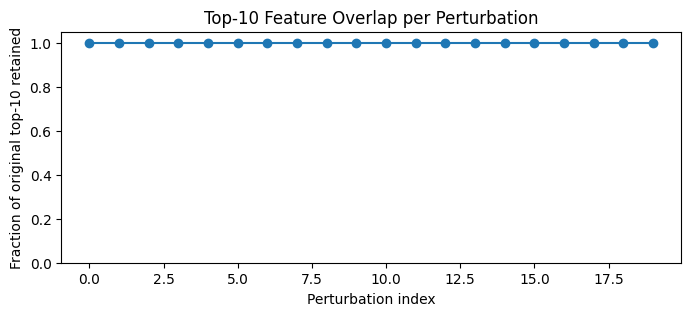

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(stability_results["SHAP Cosine Similarity"], marker="o")
plt.ylim(0.9, 1.01)
plt.title("SHAP Stability per Perturbation")
plt.xlabel("Perturbation index")
plt.ylabel("Cosine similarity to original")
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(stability_results["Top-10 Feature Overlap"], marker="o")
plt.ylim(0.0, 1.05)
plt.title("Top-10 Feature Overlap per Perturbation")
plt.xlabel("Perturbation index")
plt.ylabel("Fraction of original top-10 retained")
plt.show()